# Modelo "mesmo fato": carregar, executar e avaliar

**Em português:** o app Lume pesquisa fontes para uma notícia e precisa dizer quais delas falam **do mesmo fato**. A
regra que o app usa hoje acha poucas. Treinamos um modelo que acha mais que o dobro, errando na mesma proporção que a
regra. Este caderno carrega o modelo já treinado, dá a nota de cada fonte e mede o resultado. Roda em qualquer
computador, sem placa de vídeo: a nota do modelo de linguagem (BERTimbau) já vem calculada em `dados/`.

| Micro ponto | Em português | Em termos técnicos |
|---|---|---|
| Cada linha | uma notícia e uma fonte que a busca do app trouxe | um par (afirmação × título) |
| O que o modelo vê | 13 informações da fonte (semelhança, palavras em comum, idade, as partes da regra, o buscador...) e a nota do modelo de linguagem | 34 colunas depois do pré-processamento, mais a `nota_texto` |
| O que ele responde | "é o mesmo fato?" sim ou não | classificação binária, alvo `mesmo` |
| Quantos "sim" | uns 12 de cada 100 | classes desequilibradas (`class_weight="balanced"` no treino) |
| O modelo | uma regressão logística (um peso por informação) com a nota de um BERTimbau ajustado como informação a mais | "6B": empilhamento com nota fora da dobra |
| A régua | a regra do app: o modelo tem de achar mais que ela, sem errar mais que 3 a mais de cada 100 | contrato do ciclo 2 |
| Os três montes | estudo (aprende), simulado (escolhe), prova (mede uma vez) | treino, validação, teste; separados por notícia |

O caminho inteiro (16 etapas, decisões, erros) está no `relatorio-tecnico.md` e em `cadernos-do-pipeline/`.

## 1. Preparar o ambiente

In [1]:
import os                                   # para ler a variável do teste pequeno
import sys                                  # para o Python achar o preprocessamento.py da pasta modelo/
import json                                 # para ler as receitas e o registro do modelo
import pickle                               # para abrir o modelo salvo (.pkl)
from pathlib import Path                    # caminhos que funcionam no Windows e no Mac
import numpy as np                          # contas com vetores
import pandas as pd                         # tabelas
import matplotlib.pyplot as plt             # gráficos
from sklearn.metrics import average_precision_score   # PR-AUC: a qualidade da ordem das notas

PASTA = Path.cwd()                          # rode o caderno de dentro da pasta da entrega
sys.path.insert(0, str(PASTA / "modelo"))   # o pickle do modelo guarda o nome do módulo preprocessamento
AMOSTRA_TESTE = int(os.environ.get("ML_AMOSTRA_TESTE", "0"))   # só para conferir que o código roda; 0 = tudo

## 2. Carregar os dados

**Em português:** a tabela pronta tem uma linha por fonte, com as informações que o app tem na hora de decidir, o
rótulo dado por gente (`mesmo`) e o monte de cada fonte. Fontes da mesma notícia ficam sempre no mesmo monte.

In [2]:
# keep_default_na=False: "sem" e "ausente" são valores de verdade, não falta; só a célula vazia vira falta.
dados = pd.read_csv(PASTA / "dados" / "entradas.csv", index_col="id", keep_default_na=False, na_values=[""])
dados["mesmo"] = dados["mesmo"].map({"True": True, "False": False, True: True, False: False})  # o rótulo, 0 ou 1
# A nota do BERTimbau de cada fonte: no estudo, de uma versão que não viu a fonte; no simulado e na prova, do modelo final.
notas = pd.read_csv(PASTA / "dados" / "notas_bertimbau.csv", index_col="id")
dados["nota_texto"] = notas["nota"].reindex(dados.index)
if AMOSTRA_TESTE:                           # teste pequeno: poucas notícias inteiras de cada monte
    dados = dados[dados["grupo"].isin(dados.groupby("monte")["grupo"].apply(lambda g: sorted(g.unique())[:3]).explode())]
dados.groupby("monte").agg(fontes=("mesmo", "size"), noticias=("grupo", "nunique"), do_mesmo_fato=("mesmo", "mean")).round(3)

,fontes,noticias,do_mesmo_fato
monte,,,
estudo,7920,182,0.127
prova,4298,100,0.123
simulado,2374,49,0.126


## 3. Carregar o modelo treinado

**Em português:** são dois arquivos. O **6B** usa a nota do modelo de linguagem, que precisa de um servidor no app. O
**plano B** é a mesma conta sem essa nota, para quando o servidor não responde. Cada um tem a sua nota de corte,
escolhida no simulado no ponto em que erra o mesmo que a regra do app.

In [3]:
with open(PASTA / "modelo" / "modelo_6b.pkl", "rb") as f:
    modelo_6b = pickle.load(f)              # pré-processamento + regressão logística, juntos num Pipeline
with open(PASTA / "modelo" / "modelo_plano_b.pkl", "rb") as f:
    modelo_plano_b = pickle.load(f)
registro = json.loads((PASTA / "modelo" / "modelo_escolhido.json").read_text(encoding="utf-8"))
CORTE_6B = registro["corte"]                                    # nota mínima para dizer "mesmo fato"
CORTE_B = json.loads((PASTA / "modelo" / "decisor_plano_b.json").read_text(encoding="utf-8"))["corte"]
ENTRADAS_6B = registro["entradas"]                              # as colunas que o 6B lê
ENTRADAS_B = [c for c in ENTRADAS_6B if c != "nota_texto"]      # o plano B lê as mesmas, menos a nota do texto
print(modelo_6b)
print("corte do 6B:", round(CORTE_6B, 4), "| corte do plano B:", round(CORTE_B, 4))

Pipeline(steps=[('preproc',
                 Pipeline(steps=[('colunas',
                                  ColumnTransformer(transformers=[('numeros',
                                                                   StandardScaler(),
                                                                   ['cosseno',
                                                                    'sobreposicao',
                                                                    'nota_texto']),
                                                                  ('idade',
                                                                   Pipeline(steps=[('log',
                                                                                    FunctionTransformer(feature_names_out='one-to-one',
                                                                                                        func=<function _log_da_idade at 0x0000020EBC819900>)),
                                                       

### (Opcional) recalcular a nota do BERTimbau com os pesos

Os pesos (436 MB) vão separados, no Teams. Com eles em `modelo/bertimbau-ajustado/` e o `torch` e o `transformers` instalados,
esta célula recalcula a nota de algumas fontes e confere com a gravada. Sem os pesos, ela só avisa e segue.

In [4]:
import importlib.util                                                    # para ver se uma biblioteca está instalada
pesos = PASTA / "modelo" / "bertimbau-ajustado"
tem_bibliotecas = all(importlib.util.find_spec(m) for m in ("torch", "transformers"))
if pesos.is_dir() and tem_bibliotecas:
    import torch                                                         # a biblioteca de redes neurais
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(pesos)                           # quebra o texto em pedaços que o modelo conhece
    bert = AutoModelForSequenceClassification.from_pretrained(pesos).eval()
    amostra = dados[dados["monte"] == "simulado"].head(16)               # 16 fontes do simulado
    lote = tok(amostra["afirmacao"].tolist(), amostra["titulo"].tolist(),  # a notícia e o título, JUNTOS
               truncation=True, max_length=128, padding=True, return_tensors="pt")
    with torch.no_grad():
        nota = torch.sigmoid(bert(**lote).logits.squeeze(-1)).numpy()    # a nota de 0 a 1
    print("maior diferença para a nota gravada:", float(np.max(np.abs(nota - amostra["nota_texto"].to_numpy()))))
else:
    print("sem os pesos do BERTimbau ou sem torch/transformers: usando as notas gravadas em dados/notas_bertimbau.csv")

sem os pesos do BERTimbau ou sem torch/transformers: usando as notas gravadas em dados/notas_bertimbau.csv


## 4. Executar: a nota de cada fonte

**Em português:** para cada fonte, o modelo soma as informações com os pesos que aprendeu e devolve uma nota de 0 a 1.
Acima do corte, ele diz "mesmo fato".

In [5]:
dados["nota_6b"] = modelo_6b.predict_proba(dados[ENTRADAS_6B])[:, 1]          # [:, 1] = a chance de "mesmo"
dados["nota_plano_b"] = modelo_plano_b.predict_proba(dados[ENTRADAS_B])[:, 1]
dados["aponta_6b"] = dados["nota_6b"] >= CORTE_6B
dados["aponta_plano_b"] = dados["nota_plano_b"] >= CORTE_B
dados["aponta_regra"] = dados["regra"].isin(["mesmo_acontecimento", "detalhe_divergente"])   # a regra do app hoje
dados[["afirmacao", "titulo", "mesmo", "regra", "nota_6b", "aponta_6b"]].head(8)

,afirmacao,titulo,mesmo,regra,nota_6b,aponta_6b
id,,,,,,
par-0001,Fux derruba decisão de Dino sobre posts de Nos...,Fux derruba decisão de Dino e manda remover po...,True,mesmo_acontecimento,0.996417,True
par-0002,MP proíbe bets e determina encerramento das op...,MP que proíbe bets precisa ser aprovada pelo C...,False,contexto_relacionado,0.285507,False
par-0003,Fux derruba decisão de Dino sobre posts de Nos...,Flávio recorre a Fux para derrubar post sobre ...,False,outro_acontecimento,0.821067,False
par-0004,"Em meio à corrida eleitoral, inadimplência vol...",Inadimplência de crédito recorde atinge 5% em ...,True,contexto_relacionado,0.850170,False
par-0005,Fux derruba decisão de Dino sobre posts de Nos...,Fux derruba decisão de Dino sobre postagens de...,True,mesmo_acontecimento,0.998231,True
par-0006,Flamengo é o primeiro clube a entrar com pedid...,Campeonato Brasileiro de Futebol de 2026 - Sér...,False,outro_acontecimento,0.041289,False
par-0007,Fux derruba decisão de Dino sobre posts de Nos...,Fux derruba decisão de Dino e manda excluir po...,True,mesmo_acontecimento,0.997281,True
par-0008,"Em meio à corrida eleitoral, inadimplência vol...","Com endividamento em nível recorde, inadimplên...",True,outro_acontecimento,0.904249,True


## 5. As medidas

**Em português:** duas perguntas por decisor. **Acha quanto?** De cada 10 fontes que são o mesmo fato, quantas ele
aponta (cobertura, ou *recall*). **Erra quanto?** Do que ele mostra, quanto está certo (precisão). A faixa de incerteza
sai de sortear notícias inteiras 2.000 vezes: fontes da mesma notícia não são independentes.

In [6]:
def precisao_e_cobertura(y, aponta):
    """Precisão (do que aponta, quanto é mesmo) e cobertura (do que é mesmo, quanto aponta)."""
    y, aponta = np.asarray(y, dtype=bool), np.asarray(aponta, dtype=bool)
    precisao = (y & aponta).sum() / max(aponta.sum(), 1)
    cobertura = (y & aponta).sum() / max(y.sum(), 1)
    return float(precisao), float(cobertura)


def faixa_da_diferenca(y, aponta_a, aponta_b, grupos, n=2000, semente=20261008):
    """Cobertura de A menos a de B, com a faixa de 95% sorteando notícias inteiras (com reposição)."""
    y, aponta_a, aponta_b = (np.asarray(v, dtype=bool) for v in (y, aponta_a, aponta_b))
    grupos = np.asarray(grupos)
    linhas_de = {g: np.flatnonzero(grupos == g) for g in np.unique(grupos)}     # as fontes de cada notícia
    nomes = sorted(linhas_de)
    rng = np.random.default_rng(semente)
    difs = []
    for _ in range(n):
        idx = np.concatenate([linhas_de[g] for g in rng.choice(nomes, size=len(nomes), replace=True)])
        difs.append(precisao_e_cobertura(y[idx], aponta_a[idx])[1] - precisao_e_cobertura(y[idx], aponta_b[idx])[1])
    diferenca = precisao_e_cobertura(y, aponta_a)[1] - precisao_e_cobertura(y, aponta_b)[1]
    return diferenca, float(np.percentile(difs, 2.5)), float(np.percentile(difs, 97.5))


def placar(parte, decisores, regua):
    """Uma linha por decisor: acha de cada 10, precisão, PR-AUC (se há nota) e a diferença para a régua."""
    y = parte["mesmo"].to_numpy()
    linhas = []
    for nome, (aponta, nota) in decisores.items():
        p, c = precisao_e_cobertura(y, parte[aponta])
        d, de, ate = faixa_da_diferenca(y, parte[aponta], parte[regua], parte["grupo"])
        linhas.append({"decisor": nome, "acha de cada 10": round(10 * c, 2), "precisão": round(p, 3),
                       "PR-AUC": round(average_precision_score(y, parte[nota]), 3) if nota else None,
                       "contra a régua (de cada 10)": round(10 * d, 2), "faixa": f"{10 * de:+.2f} a {10 * ate:+.2f}"})
    return pd.DataFrame(linhas).set_index("decisor")

## 6. No simulado (onde o corte foi escolhido)

**Em português:** o simulado são 49 notícias que o modelo não viu no treino. Foi aqui que escolhemos o modelo e a nota
de corte, então o número sai um pouco otimista. O que vale é a prova, logo abaixo.

**Uma diferença de arredondamento:** aqui o 6B acha 8,07 de cada 10; na etapa 12 do pipeline, 8,10. O corte foi gravado com 6 casas (0,874239), e a única fonte do simulado que estava exatamente no corte (nota 0,8742385) ficou de fora: uma fonte em 300. A prova e a receita do app sempre usaram o corte gravado, então os números da prova não mudam.

In [7]:
simulado = dados[dados["monte"] == "simulado"]
placar(simulado, {"regra do app": ("aponta_regra", None), "plano B": ("aponta_plano_b", "nota_plano_b"),
                  "6B": ("aponta_6b", "nota_6b")}, regua="aponta_regra")

,acha de cada 10,precisão,PR-AUC,contra a régua (de cada 10),faixa
decisor,,,,,
regra do app,4.13,0.855,NaN,0.00,+0.00 a +0.00
plano B,7.53,0.856,0.902,3.40,+2.18 a +4.84
6B,8.07,0.855,0.916,3.93,+2.67 a +5.37


## 7. Na prova (rodada 4, 100 notícias que ninguém tinha olhado)

**Em português:** a prova foi aberta **uma vez**, em 08/10/2026, por um cofre que confere a pilha e conta as
aberturas; aqui o mesmo resultado é refeito para conferência. Além da regra do app com o nosso ajuste do
MPNet, entra a **regra do MVP do grupo** (o MPNet original, sem ajuste), refeita em `src/comparar_com_o_mvp.py`.

**O contrato:** (1) achar mais que a regra, com a faixa toda acima de zero; (2) precisão no máximo 3 pontos abaixo da
regra.

In [8]:
prova = dados[dados["monte"] == "prova"].copy()
mvp = pd.read_csv(PASTA / "dados" / "regra_do_mvp_rodada_4.csv", index_col="id")["regra_mvp"]
prova["aponta_mvp"] = mvp.reindex(prova.index).isin(["mesmo_acontecimento", "detalhe_divergente"])
resultado_prova = placar(prova, {"regra do MVP (Guilherme)": ("aponta_mvp", None),
                                 "regra do app (MPNet ajustado)": ("aponta_regra", None),
                                 "plano B": ("aponta_plano_b", "nota_plano_b"), "6B": ("aponta_6b", "nota_6b")},
                         regua="aponta_regra")
p6, c6 = precisao_e_cobertura(prova["mesmo"], prova["aponta_6b"])
pr, cr = precisao_e_cobertura(prova["mesmo"], prova["aponta_regra"])
d, de, ate = faixa_da_diferenca(prova["mesmo"], prova["aponta_6b"], prova["aponta_regra"], prova["grupo"])
print(f"exigência 1, achar mais: {10 * d:+.2f} de cada 10 [{10 * de:+.2f}; {10 * ate:+.2f}] ->", "passa" if de > 0 else "não passa")
print(f"exigência 2, precisão: {100 * (p6 - pr):+.1f} pontos (limite -3) ->", "passa" if p6 - pr >= -0.03 else "não passa")
resultado_prova

exigência 1, achar mais: +4.01 de cada 10 [+2.82; +5.16] -> passa
exigência 2, precisão: -0.7 pontos (limite -3) -> passa


,acha de cada 10,precisão,PR-AUC,contra a régua (de cada 10),faixa
decisor,,,,,
regra do MVP (Guilherme),3.48,0.733,NaN,-0.09,-0.31 a +0.00
regra do app (MPNet ajustado),3.57,0.750,NaN,0.00,+0.00 a +0.00
plano B,7.13,0.721,0.756,3.55,+2.53 a +4.54
6B,7.58,0.743,0.814,4.01,+2.82 a +5.16


## 8. A cena das 100 fontes, na prova

**Em português:** de cada 100 fontes que a busca trouxe, quantas cada um acerta e erra.

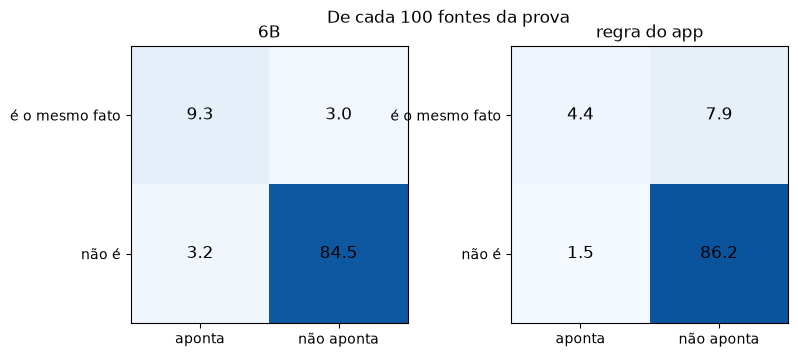

In [9]:
def cena(parte, aponta):
    y, a, n = parte["mesmo"].to_numpy(), parte[aponta].to_numpy(), len(parte)
    return np.array([[100 * (y & a).sum() / n, 100 * (y & ~a).sum() / n],       # é o mesmo fato: aponta / deixa passar
                     [100 * (~y & a).sum() / n, 100 * (~y & ~a).sum() / n]])    # não é: aponta por engano / fica quieto

fig, eixos = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (nome, col) in zip(eixos, [("6B", "aponta_6b"), ("regra do app", "aponta_regra")]):
    m = cena(prova, col)
    ax.imshow(m, cmap="Blues", vmin=0, vmax=100)
    for (i, j), v in np.ndenumerate(m):
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1], ["aponta", "não aponta"])
    ax.set_yticks([0, 1], ["é o mesmo fato", "não é"])
    ax.set_title(nome)
fig.suptitle("De cada 100 fontes da prova")
plt.show()

## 9. Onde o modelo erra: a idade da fonte

**Em português:** a fonte do mesmo dia é quase sempre certa; a de semanas antes, muitas vezes é o mesmo assunto, não o
mesmo fato. Por isso, no app, o selo "provável mesmo fato" só aparece para fonte do mesmo dia ou da véspera.

In [10]:
faixa = (pd.cut(prova["idade_dias"], [-10, 1, 30, 10**6], labels=["mesmo dia ou véspera", "2 a 30 dias", "mais de um mês"])
         .cat.add_categories("sem data").fillna("sem data"))       # sem data vira uma faixa, não some
linhas = []
for nome, parte in prova.groupby(faixa, observed=True):
    p, c = precisao_e_cobertura(parte["mesmo"], parte["aponta_6b"])
    linhas.append({"idade da fonte": nome, "fontes": len(parte), "do mesmo fato": int(parte["mesmo"].sum()),
                   "6B acha de cada 10": round(10 * c, 2), "6B acerta, do que mostra": round(p, 3)})
pd.DataFrame(linhas).set_index("idade da fonte")

,fontes,do mesmo fato,6B acha de cada 10,"6B acerta, do que mostra"
idade da fonte,,,,
mesmo dia ou véspera,781,364,8.46,0.851
2 a 30 dias,786,123,6.99,0.551
mais de um mês,1368,38,1.32,0.250
sem data,1363,4,5.00,1.000


## 10. (Opcional) refazer o treino e conferir que dá o mesmo modelo

**Em português:** o modelo salvo veio deste treino. Aqui ele é refeito com o estudo (a nota do texto de cada fonte vem
de uma versão do BERTimbau que não a viu) e comparado peso a peso com o salvo. O treino do BERTimbau em si está em
`cadernos-do-pipeline/` e no `treinar_cross_encoder.py` do repositório (precisa de placa de vídeo).

In [11]:
import copy                                        # para fazer uma cópia do modelo ainda sem treino
estudo = dados[dados["monte"] == "estudo"]
refeito = copy.deepcopy(modelo_6b)                 # mesmos passos e mesmos parâmetros (C=0,03, classes equilibradas)
refeito.fit(estudo[ENTRADAS_6B], estudo["mesmo"])  # o treino: aprende os pesos só com o estudo
pesos_refeitos = refeito.named_steps["logistica"].coef_
pesos_salvos = modelo_6b.named_steps["logistica"].coef_
if pesos_refeitos.shape == pesos_salvos.shape:     # no teste pequeno faltam categorias, e o número de colunas muda
    print("maior diferença entre os pesos refeitos e os salvos:", float(np.max(np.abs(pesos_refeitos - pesos_salvos))))
else:
    print("teste pequeno: o estudo da amostra não tem todas as categorias; a conferência vale com os dados inteiros")

maior diferença entre os pesos refeitos e os salvos: 0.0


## O que ler a seguir

- `relatorio-tecnico.md`: preparo dos dados, critérios de escolha, métricas, desafios e aprendizados.
- `figuras/`: as figuras das 16 etapas; `cadernos-do-pipeline/`: o código de cada etapa.
- O repositório da residência (`ml_pipeline/PIPELINE.md`): o diário de cada etapa, com o que deu errado.